# Structure Learning in Bayesian Networks

example from:
https://blog.gopenai.com/llms-for-causal-discovery-745e2cba0b59

In [1]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 10.7 MB/s eta 0:00:00


In [2]:
!apt install libgraphviz-dev
!pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4
0 upgraded, 12 newly installed, 0 to remove and 2 not upgraded.
Need to get 2,496 kB of archives.
After this operation, 7,963 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2.

In [4]:
import pandas as pd

In [16]:
# LOAD THE DATA

df = pd.read_csv("https://raw.githubusercontent.com/pgmpy/pgmpy/refs/heads/dev/pgmpy/tests/test_estimators/testdata/adult_proc.csv", index_col=0)
df.Age = pd.Categorical(
    df.Age,
    categories=["<21", "21-30", "31-40", "41-50", "51-60", "61-70", ">70"],
    ordered=True,
)
df.Education = pd.Categorical(
    df.Education,
    categories=[
        "Preschool",
        "1st-4th",
        "5th-6th",
        "7th-8th",
        "9th",
        "10th",
        "11th",
        "12th",
        "HS-grad",
        "Some-college",
        "Assoc-voc",
        "Assoc-acdm",
        "Bachelors",
        "Prof-school",
        "Masters",
        "Doctorate",
    ],
    ordered=True,
)
df.HoursPerWeek = pd.Categorical(
    df.HoursPerWeek, categories=["<=20", "21-30", "31-40", ">40"], ordered=True
)
df.Workclass = pd.Categorical(df.Workclass, ordered=False)
df.MaritalStatus = pd.Categorical(df.MaritalStatus, ordered=False)
df.Occupation = pd.Categorical(df.Occupation, ordered=False)
df.Relationship = pd.Categorical(df.Relationship, ordered=False)
df.Race = pd.Categorical(df.Race, ordered=False)
df.Sex = pd.Categorical(df.Sex, ordered=False)
df.NativeCountry = pd.Categorical(df.NativeCountry, ordered=False)
df.Income = pd.Categorical(df.Income, ordered=False)

In [6]:
# calcular PC
from pgmpy.estimators import PC

est_pc = PC(df)
cpdag_pillai = est_pc.estimate(ci_test="pillai", return_type="cpdag")

/tmp/ipykernel_7205/2930601218.py:4: FutureWarning: PC is deprecated. Please use pgmpy.causal_discovery.PC instead.
  est_pc = PC(df)


  0%|          | 0/5 [00:00<?, ?it/s]

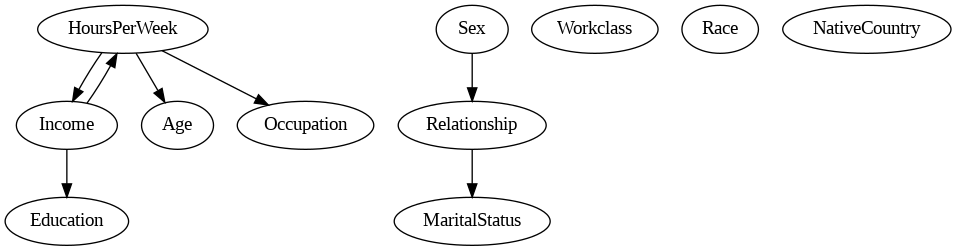

In [13]:

from IPython.display import Image

cpdag_pillai.to_graphviz().draw("adult_pillai.png", prog="dot")
Image('adult_pillai.png')

/tmp/ipykernel_7205/1005154454.py:4: FutureWarning: HillClimbSearch is deprecated. Please use pgmpy.causal_discovery.HillClimbSearch instead.
  est_hill = HillClimbSearch(df)


  0%|          | 0/1000000 [00:00<?, ?it/s]

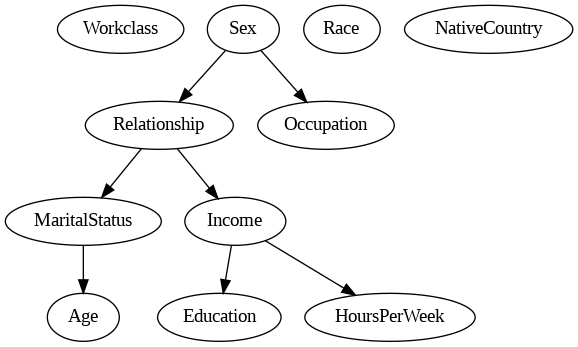

In [15]:
# calcular Hill Climb
from pgmpy.estimators import HillClimbSearch

est_hill = HillClimbSearch(df)
dag_hill = est_hill.estimate(scoring_method="bic-d")
dag_hill.to_graphviz().draw("adult_hill.png", prog="dot")
Image('adult_hill.png')